In [4]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import pandas as pd
from logic.clustering_cnn import get_clusters
from logic.database import _compute_window_current, IOS, SIGMA_WHITE
import pandas as pd
import numpy as np


# Simulation Benchmark: Finding the Accuracy Ceiling

The CNN achieves ~75% accuracy for 7 clusters. Is that because the CNN is bad, or because the physics of the simulation makes it impossible to do better?

The core problem is that the measured current at each position is not just from the amino acid at that position -> it is a Gaussian-weighted blend of the 5 amino acids in the sensing window. This blurring can drag two positions with different amino acids (and different cluster labels) to produce nearly identical currents. When that happens, no classifier can tell them apart and that is the ceiling.

<!-- ### **Step 2: Find positions that are confused by window blurring**

For each pair of positions, check if their currents are within 1σ (1 pA) of each other. These are pairs where the window blurring has dragged two different amino acids to nearly the same current value. If they also have different cluster labels, this is an unavoidable confusion —> the CNN sees the same input but is expected to output two different labels.

This uses the raw SIGMA_WHITE = 1 pA, but in practice the effective noise is lower (~0.2 pA) because `mean_current` is averaged over ~25 samples per step. So this is a conservative (pessimistic) estimate of confusion. -->

### **K-mer space coverage**

How much of the possible 5-mer space does the training data cover? With 20 amino acids and 5-mer windows there are 20^5 = 3.2 million possible k-mers. With 10,000 traces of 20 amino acids each, you get 160,000 k-mer instances. How many of those are unique, and what fraction of the full space does that represent?

In [8]:
db = pd.read_csv('../data/nanopore_trace_database.csv')
sequences = db.groupby('trace_id')['peptide_sequence'].first()

kmers = []
for seq in sequences:
    for i in range(len(seq) - 5 + 1):
        kmers.append(seq[i:i+5])

print(f"Total 5-mer instances: {len(kmers)}")
print(f"Unique 5-mers seen:    {len(set(kmers))}")
print(f"Total possible 5-mers: {20**5:,}")
print(f"Coverage:              {len(set(kmers)) / 20**5 * 100:.2f}%")


Total 5-mer instances: 160000
Unique 5-mers seen:    156038
Total possible 5-mers: 3,200,000
Coverage:              4.88%


#### **since we're doing 7-way classification and not 20-way classification with the clusters, cluster diversity is more important**

In [11]:
features = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
features = features.copy()
possible_sequences = []
sequences = features.groupby('trace_id')
n_clusters = 7
aa_to_cluster = get_clusters(n_clusters)
features['label'] = features['amino_acid'].map(aa_to_cluster) - 1
features.head()
for name, seq in sequences:
    for i in range(len(seq) - 5 + 1):
        possible_sequences.append(''.join(seq['label'].iloc[i:i+5].astype(str)))
print(f"Total 5-mer instances: {len(possible_sequences)}")
print(f"Unique 5-mers seen:    {len(set(possible_sequences))}")
print(f"Total possible 5-mers: {n_clusters**5}")
print(f"Coverage:              {len(set(possible_sequences)) / n_clusters**5 * 100:.2f}%")

Total 5-mer instances: 159981
Unique 5-mers seen:    16413
Total possible 5-mers: 16807
Coverage:              97.66%


In [12]:
from collections import Counter
kmer_counts = Counter(kmers)
counts = list(kmer_counts.values())
print(f"Seen only once:  {sum(1 for c in counts if c == 1)}")
print(f"Seen 2-5 times:  {sum(1 for c in counts if 2 <= c <= 5)}")
print(f"Seen >5 times:   {sum(1 for c in counts if c > 5)}")


Seen only once:  152137
Seen 2-5 times:  3901
Seen >5 times:   0


Almost every k-mer is seen only once there are virtually no repeats. This confirms the CNN cannot be memorising k-mers. It must be learning something about the physics, or using the surrounding currents that are int he feature vectors to learn

In [64]:
# # for a test peptide, how many of its 16 k-mers were seen in training?
# test_pep = ''.join(random.choices(list(AA_PROPERTIES.keys()), k=20))

# seen_training = set(kmers)
# for i in range(len(test_pep) - 5 + 1):
#     kmer = test_pep[i:i+5]
#     seen = kmer in seen_training
#     print(f"pos {i:2d}: {kmer}  {'seen in training' if seen else 'UNSEEN'}")


Even though every k-mer in a test peptide is unseen, the CNN can still generalise because each amino acid has been seen in ~7,800 different neighbour contexts during training. The CNN has learned what each amino acid contributes to the current regardless of what surrounds it.

In [16]:
from collections import defaultdict
aa_contexts = defaultdict(set)
sequences = db.groupby('trace_id')['peptide_sequence'].first().tolist()

for seq in sequences:
    for i in range(2, len(seq) - 2):  # full windows only
        center = seq[i]
        context = seq[i-2:i+3]
        aa_contexts[center].add(context)

for aa in sorted(aa_contexts.keys()):
    print(f"{aa}: {len(aa_contexts[aa])} unique contexts seen")


A: 7800 unique contexts seen
C: 7604 unique contexts seen
D: 7850 unique contexts seen
E: 7854 unique contexts seen
F: 7768 unique contexts seen
G: 7926 unique contexts seen
H: 7908 unique contexts seen
I: 7800 unique contexts seen
K: 7729 unique contexts seen
L: 7767 unique contexts seen
M: 7792 unique contexts seen
N: 7839 unique contexts seen
P: 7853 unique contexts seen
Q: 7764 unique contexts seen
R: 7754 unique contexts seen
S: 7830 unique contexts seen
T: 7810 unique contexts seen
V: 7932 unique contexts seen
W: 7786 unique contexts seen
Y: 7672 unique contexts seen


### **Current distribution overlap per cluster**
Plotted the distribution of measured mean_current values for each cluster across all 10,000 traces. Where two clusters' histograms overlap, the CNN receives the same current value with two different cluster labels in its training data, it cannot learn to separate those cases.

The distributions are wide (not tight Gaussians) because the window blurring shifts each amino acid's current depending on its neighbours. The overlap between clusters is the direct visual representation of the ceiling.

This is for the worst case scenario where only the center current is known

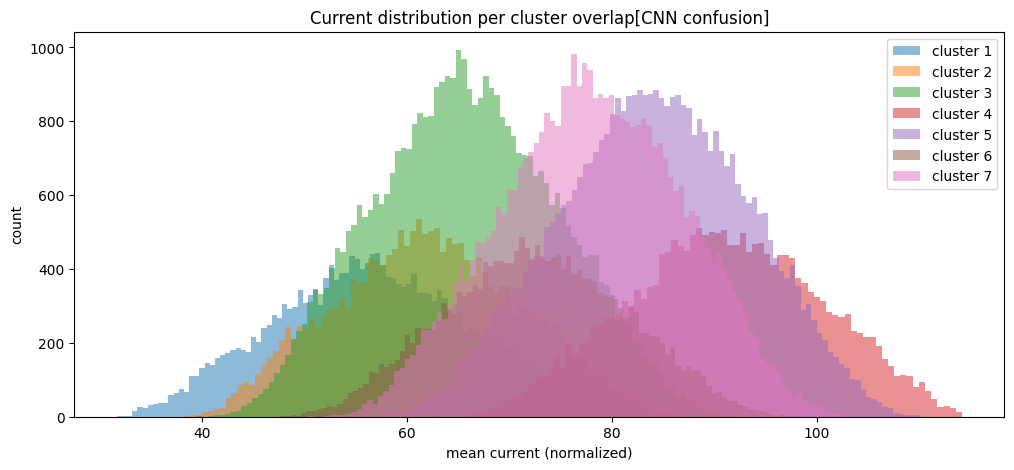

In [5]:
df = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
aa_to_cluster = get_clusters(7)
df['cluster'] = df['amino_acid'].map(aa_to_cluster)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
for cluster_id in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cluster_id]['mean_current']
    ax.hist(subset, bins=100, alpha=0.5, label=f'cluster {cluster_id}')

ax.set_xlabel('mean current (normalized)')
ax.set_ylabel('count')
ax.legend()
plt.title('Current distribution per cluster overlap[CNN confusion]')
plt.show()




In [23]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# feature_cols = ['mean_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
# X = df[feature_cols].dropna()
# labels = df.loc[X.index, 'cluster']
# lda = LinearDiscriminantAnalysis(n_components=2)
# proj = lda.fit_transform(X, labels)

# fig, ax = plt.subplots(figsize=(8, 6))
# for c in sorted(labels.unique()):
#     mask = labels == c
#     ax.scatter(proj[mask, 0], proj[mask, 1], s=1, alpha=0.3, label=f'cluster {c}')
# ax.legend()
# plt.title('LDA of classifier features colored by cluster')
# plt.show()


In [ ]:
# print(lda.scalings_)  # shape (5, 6) — 5 features, 6 discriminant directions
# for i, col in enumerate(feature_cols):
#     print(f"{col}: LD1={lda.scalings_[i,0]:.3f}, LD2={lda.scalings_[i,1]:.3f}")


[[ 0.8022342   0.17796821  0.04376633  0.2305726   0.03066905]
 [ 1.07029195  0.51985393  0.98165114  0.50817735  0.11886658]
 [-0.78545421 -0.34900814 -0.2218877  -0.2677814   0.04199689]
 [-0.78693967 -0.15673485  0.06154486 -0.4462576  -0.12830765]
 [ 1.07362105 -0.08389274 -0.15934875  1.2106596  -0.06321047]]
mean_current: LD1=0.802, LD2=0.178
mean_minus2: LD1=1.070, LD2=0.520
mean_minus1: LD1=-0.785, LD2=-0.349
mean_plus1: LD1=-0.787, LD2=-0.157
mean_plus2: LD1=1.074, LD2=-0.084


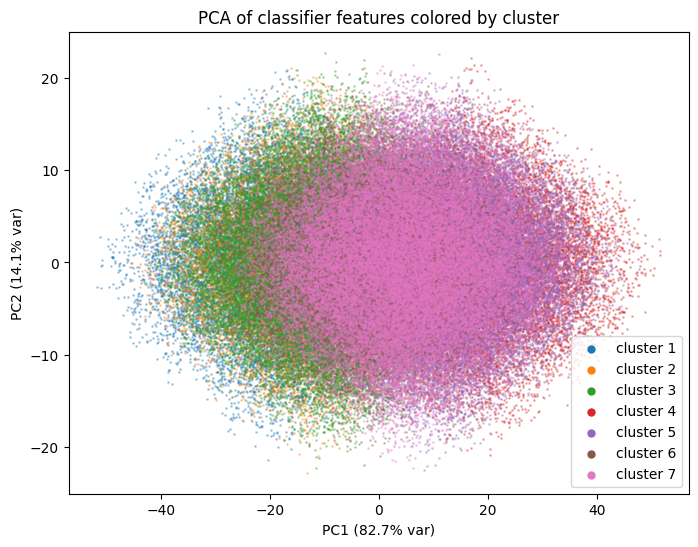

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

feature_cols = ['mean_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
X = df[feature_cols].dropna()
labels = df.loc[X.index, 'cluster']
pca = PCA(n_components=2)
proj = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(labels.unique()):
    mask = labels == c
    ax.scatter(proj[mask, 0], proj[mask, 1], s=1, alpha=0.3, label=f'cluster {c}')
ax.legend()
leg = ax.legend(markerscale=5)
for handle in leg.legend_handles:
    handle.set_alpha(1.0)



plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA of classifier features colored by cluster')
plt.show()


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
feature_cols = ['mean_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
X = df[feature_cols].dropna()
# Fit PCA (use all components to see the full variance breakdown)
pca = PCA()

pca.fit(X)  # X is your data matrix

# Plot scree plot
explained_variance = pca.explained_variance_ratio_
print(explained_variance)


[0.8267139  0.14080205 0.02859857 0.00275196 0.00113352]


### Bhattacharyya coefficient (BC): statistical measure used to quantify the amount of overlap between two probability distributions or samples

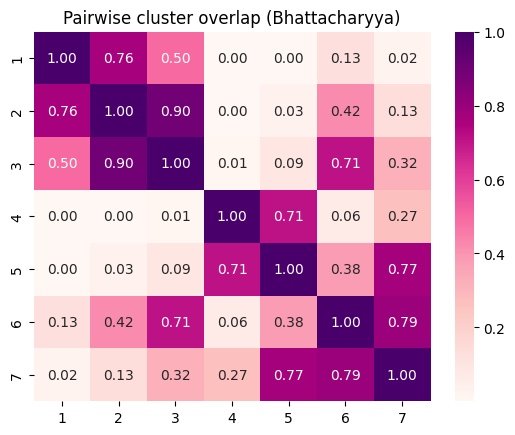

In [12]:
import numpy as np
from scipy.stats import multivariate_normal

def bhattacharyya(mu1, cov1, mu2, cov2):
    cov_avg = (cov1 + cov2) / 2
    delta = mu1 - mu2

    # mathemeatical definition of coefficient for multivariate Gaussians

    #measures how far apart the cluster centers are
    # if they're far apart relative to the variance, this will be large, and lead to a smaller overlap
    term1 = 0.125 * delta @ np.linalg.inv(cov_avg) @ delta

    # measures how different the shapes/spreads of the two dists are
    # if one cluster is very tight and hte other is wide,this will be large, low overlap
    term2 = 0.5 * np.log(np.linalg.det(cov_avg) / np.sqrt(np.linalg.det(cov1) * np.linalg.det(cov2)))

    #if term 1 and 2 are both 0, --> (exp(0) = 1) complete overlap
    # if term 1  and/or 2 exp(-large) ~ 0, no overlap
    return np.exp(-(term1 + term2))

clusters = sorted(labels.unique())
feature_cols = ['mean_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
X = df[feature_cols].dropna()
labels = df.loc[X.index, 'cluster']
# print(labels.unique())
overlap = pd.DataFrame(index=clusters, columns=clusters, dtype=float)
for i in clusters:
    for j in clusters:
        Xi = X[labels == i].values
        # print(Xi.shape)
        Xj = X[labels == j].values
        # np.cov gives you a 5×5 covariance matrix 
        # that captures both the variance of each feature and how they co-vary with each other.
        overlap.loc[i, j] = bhattacharyya(Xi.mean(0), np.cov(Xi.T), Xj.mean(0), np.cov(Xj.T))


import seaborn as sns
sns.heatmap(overlap, annot=True, fmt='.2f', cmap='RdPu')
plt.title('Pairwise cluster overlap (Bhattacharyya)')
plt.show()


In [13]:
feature_cols = [
    'mean_current',
    'mean_minus2',
    'mean_minus1',
    'mean_plus1',
    'mean_plus2'
]
from tensorflow.keras.models import load_model

model_7 = load_model('model7.keras')
X_test_7 = np.load('X_test_7.npy')
y_test_7 = np.load('y_test_7.npy')

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


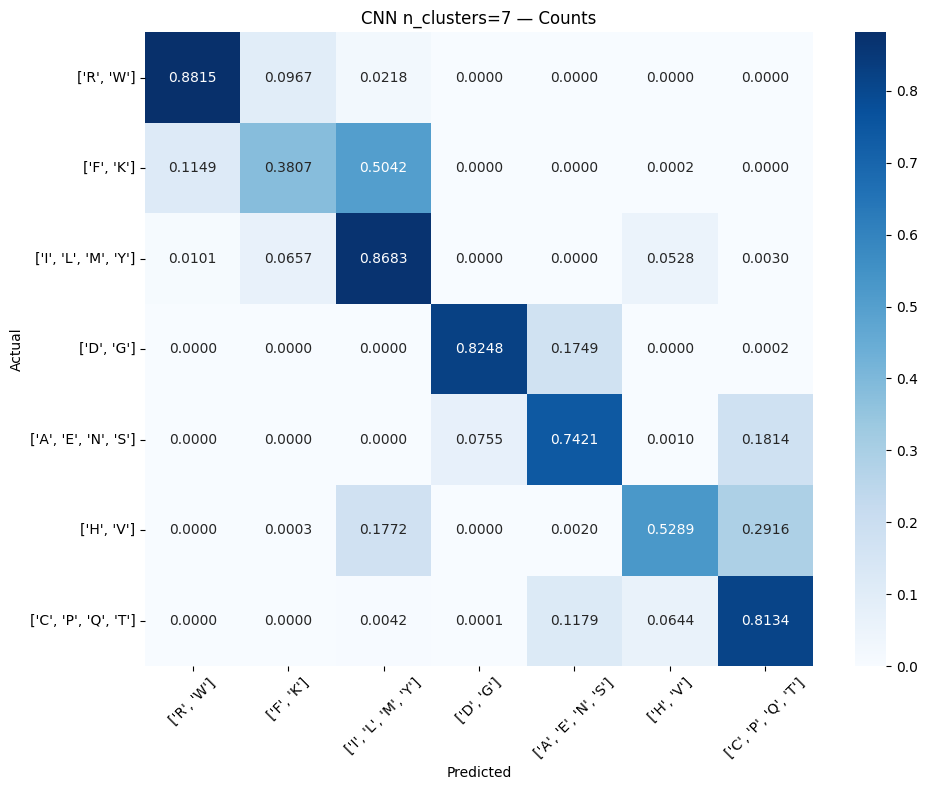

                      precision    recall  f1-score   support

          ['R', 'W']       0.87      0.88      0.87      3982
          ['F', 'K']       0.63      0.38      0.47      4022
['I', 'L', 'M', 'Y']       0.71      0.87      0.78      7897
          ['D', 'G']       0.84      0.82      0.83      4019
['A', 'E', 'N', 'S']       0.78      0.74      0.76      8091
          ['H', 'V']       0.69      0.53      0.60      3923
['C', 'P', 'Q', 'T']       0.71      0.81      0.76      8026

            accuracy                           0.75     39960
           macro avg       0.75      0.72      0.73     39960
        weighted avg       0.74      0.75      0.74     39960



In [15]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_proba_7 = model_7.predict(X_test_7)           # (n_traces, 20, n_clusters)
y_pred_7 = np.argmax(y_pred_proba_7, axis=-1)      # (n_traces, 20)

y_pred_flat_7 = y_pred_7.flatten()                 # (n_traces * 20,)
y_test_flat_7 = y_test_7.flatten()                 # (n_traces * 20,)

cm = confusion_matrix(y_test_flat_7, y_pred_flat_7)
# cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n_clusters = 7
aa_to_cluster = get_clusters(n_clusters)
cluster_to_aas = defaultdict(list)
for aa, cluster in aa_to_cluster.items():
    cluster_to_aas[cluster].append(aa)

# 0-indexed to match model output
tick_labels = [str(sorted(cluster_to_aas[c + 1])) for c in range(n_clusters)]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.4f', cmap='Blues', ax=ax,
            xticklabels=tick_labels, yticklabels=tick_labels)

# sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
#             xticklabels=tick_labels, yticklabels=tick_labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'CNN n_clusters={n_clusters} — Counts')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()
print(classification_report(y_test_flat_7, y_pred_flat_7, target_names=tick_labels))




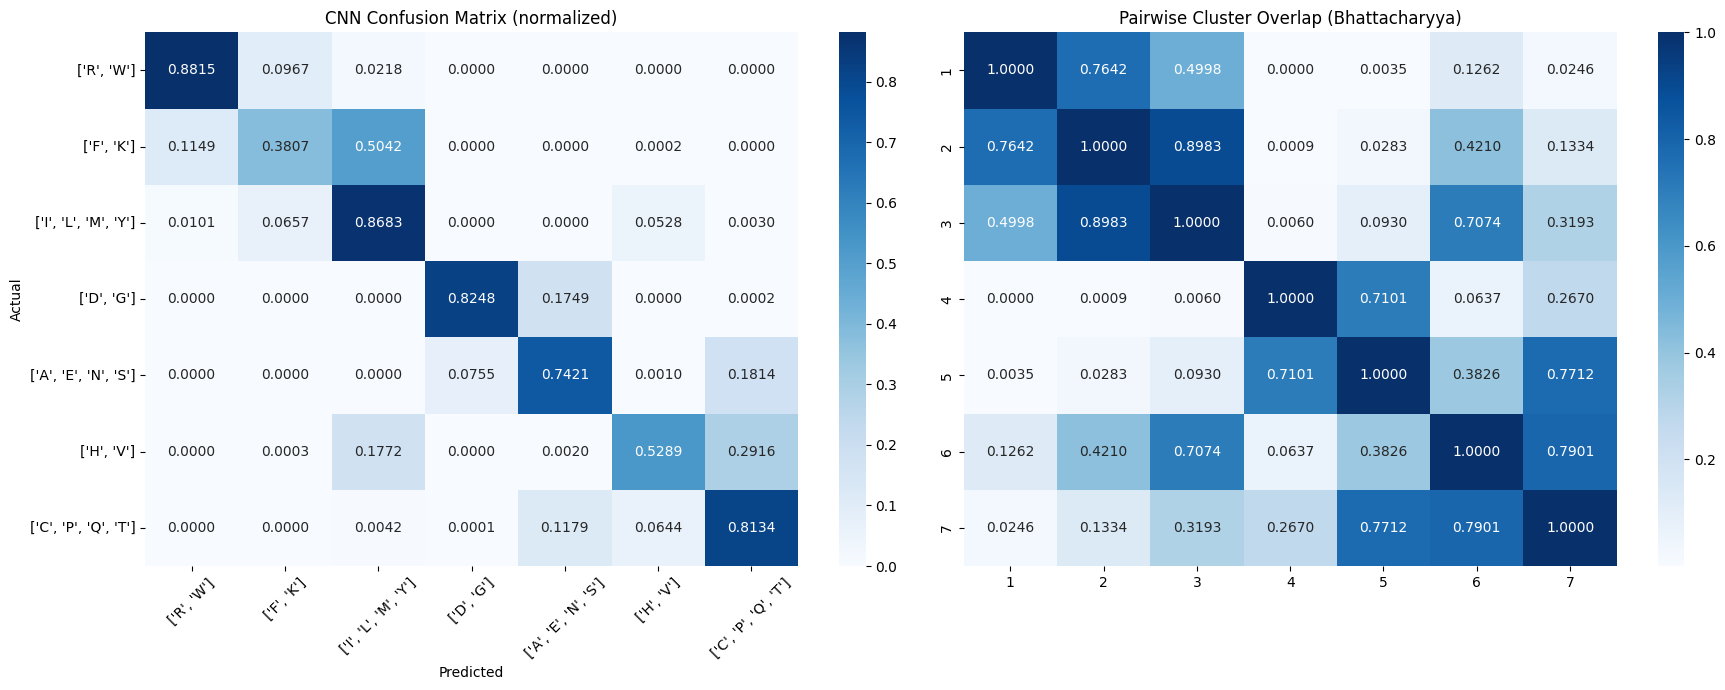

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_norm, annot=True, fmt='.4f', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('CNN Confusion Matrix (normalized)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(overlap, annot=True, fmt='.4f', cmap='Blues', ax=axes[1])
axes[1].set_title('Pairwise Cluster Overlap (Bhattacharyya)')

plt.tight_layout()
plt.show()


In [ ]:
# fig, ax = plt.subplots(1, 1, figsize=(9, 9))
# sns.heatmap(np.log(overlap - cm_norm), annot=True, fmt='.4f', cmap='Blues')
for i in range(n_clusters):
    

(7, 7)

In [ ]:
import numpy as np
# measures how much each feature contributes by destroying it and seeing how the accuracy drops

def permutation_importance(model, X, y, feature_names):
    baseline = model.evaluate(X, y, verbose=0)[1]  # baseline accuracy
    importances = []
    # for each feature, shuffle that feature's values randomly across all samples 
    # and reevaluate on the corrupted data and record the new(lower) accuracy
    
    for i in range(X.shape[-1]):
        X_perm = X.copy()
        X_perm[:, :, i] = np.random.permutation(X_perm[:, :, i])
        score = model.evaluate(X_perm, y, verbose=0)[1]
        importances.append(baseline - score)
    return dict(zip(feature_names, importances))

In [ ]:
feature_importances = permutation_importance(model_7, X_test_7, y_test_7, feature_cols)
print("Permutation Importances:", feature_importances)

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Permutation Importances: {'mean_current': 0.4544544517993927, 'mean_minus2': 0.02642643451690674, 'mean_minus1': 0.3198949694633484, 'mean_plus1': 0.2941691279411316, 'mean_plus2': 0.021021127700805664}


In [56]:
# df = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
# aa_to_cluster = get_clusters(7)
# df['cluster'] = df['amino_acid'].map(aa_to_cluster)

# # for each step, get the cluster pattern of its 5-mer window
# # you already have mean_current and the neighbour currents as features
# feature_cols = ['mean_minus2', 'mean_minus1', 'mean_current', 'mean_plus1', 'mean_plus2']
# df_clean = df.dropna(subset=feature_cols)

# # find pairs of steps with different cluster labels but similar mean_current
# confused = 0
# total = 0
# N_SAMPLES = 25
# sigma_effective = SIGMA_WHITE / np.sqrt(N_SAMPLES)

# for cluster_a in sorted(df_clean['cluster'].unique()):
#     for cluster_b in sorted(df_clean['cluster'].unique()):
#         if cluster_b <= cluster_a:
#             continue
#         curr_a = df_clean[df_clean['cluster'] == cluster_a]['mean_current']
#         curr_b = df_clean[df_clean['cluster'] == cluster_b]['mean_current']
#         # how many steps from cluster_a fall within noise of cluster_b's range?
#         overlap = ((curr_a >= curr_b.min()) & (curr_a <= curr_b.max())).sum()
#         print(f"cluster {cluster_a} vs {cluster_b}: {overlap} overlapping steps")


### **Step 3: Empirical ceiling: position identification accuracy over 1000 random peptides**

For each random peptide, add realistic noise to each position's current (σ_effective = σ_white / √25, since mean_current averages ~25 samples --> from 5ms dwell* 5000 Hz sampling freq), then ask: using a perfect nearest-neighbour classifier that knows all 20 true currents, can it identify the correct **position**? 

The mean ceiling tells you: on average, what fraction of positions can be correctly identified from the current signal alone, even with a perfect classifier. This is a lower bound on the true ceiling —> the CNN also uses the 4 neighbouring step currents as features, which helps it partially recover confused positions.

In [ ]:
import random
from logic.database import AA_PROPERTIES
import numpy as np
random.seed(42)
N_SAMPLES = 25  # approximate samples per step
sigma_effective = SIGMA_WHITE / np.sqrt(N_SAMPLES)
ceilings = []
for _ in range(1000):
    pep = ''.join(random.choices(list(AA_PROPERTIES.keys()), k=20))
    currents = [_compute_window_current(pep, i) for i in range(20)]
    correct = 0
    noisy = [c + np.random.normal(0, sigma_effective) for c in currents]
    for i in range(20):
        predicted = min(range(20), key=lambda j: abs(noisy[i] - currents[j]))
        if predicted == i:
            correct += 1
    ceilings.append(correct / 20 * 100)

print(f"Mean ceiling: {np.mean(ceilings):.1f}%")
print(f"Min ceiling:  {np.min(ceilings):.1f}%")
print(f"Max ceiling:  {np.max(ceilings):.1f}%")


Mean ceiling: 87.9%
Min ceiling:  60.0%
Max ceiling:  100.0%


### **Cluster accuracy ceiling**

Score by **cluster accuracy**. Two positions being confused only counts as an error if they belong to **different clusters** , sort of matching what the CNN is actually asked to do. IN reality the CNN has access to more features than just hte mean current

In [ ]:
import random
from logic.database import AA_PROPERTIES
random.seed(42)
N_SAMPLES = 25  # approximate samples per step
aa_to_cluster = get_clusters(n_clusters=7)
sigma_effective = SIGMA_WHITE / np.sqrt(N_SAMPLES)
ceilings = []
for _ in range(1000):
    pep = ''.join(random.choices(list(AA_PROPERTIES.keys()), k=20))
    currents = [_compute_window_current(pep, i) for i in range(20)]
    correct = 0
    noisy = [c + np.random.normal(0, sigma_effective) for c in currents]
    for i in range(20):
        predicted = min(range(20), key=lambda j: abs(noisy[i] - currents[j]))
        if aa_to_cluster[pep[predicted]] == aa_to_cluster[pep[i]]:
            correct += 1
    ceilings.append(correct / 20 * 100)

print(f"Mean ceiling: {np.mean(ceilings):.1f}%")
print(f"Min ceiling:  {np.min(ceilings):.1f}%")
print(f"Max ceiling:  {np.max(ceilings):.1f}%")
